# Phising Email KeyBERT



KeyBERT is a Python library for keyword extraction and keyphrase extraction. It is built on top of the Hugging Face Transformers library and leverages pre-trained transformer models, such as BERT, to extract key phrases or keywords from a given text. KeyBERT is particularly useful for tasks like document summarization, content analysis, and information retrieval.

In [1]:
!pip install keybert

  Preparing metadata (setup.py) ... - \ done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.7/224.7 kB 6.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 71.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 401.7/401.7 kB 39.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.1/316.1 kB 30.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 89.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 59.3 MB/s eta 0:00:00
  Created wheel for keybert: filename=keybert-0.8.4-py3-none-any.whl size=39231 sha256=702e831b63b173d096745e555102f29fd3b3996b8ffd876da809c84b5ebc39b1
  Stored in directory: /root/.cache/pip/wheels/97/ef/4c/6588bd7072b0cc04225b40e639b991e49ebd4e21fb81f0acee
Successfully built keybert
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2023.4.0
    Uninstalling fsspec-2023.4.0:
      Successfully uninstalled fsspec-2023.4.0
  Attempting uninstall: 

In [2]:
import numpy as np 
import pandas as pd 
import random
import os
from keybert import KeyBERT
import matplotlib.pyplot as plt

/opt/conda/lib/python3.10/site-packages/sentence_transformers/cross_encoder/CrossEncoder.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange
/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [3]:
model = KeyBERT('distilbert-base-nli-mean-tokens')

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/4.02k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/550 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/450 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

1_Pooling/config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [4]:
data = pd.read_csv('/kaggle/input/phishing-email-dataset/CEAS_08.csv')
datai=data.iloc[:,4:6].dropna().reset_index(drop=True)
print(len(datai))
datai['keys']='-'
display(datai)

39154


,body,label,keys
0,"Buck up, your troubles caused by small dimensi...",1,-
1,\nUpgrade your sex and pleasures with these te...,1,-
2,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,-
3,Would anyone object to removing .so from this ...,0,-
4,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,-
...,...,...,...
39149,\n\nCNN Alerts: My Custom Alert\n\n\n\n\n\n\n ...,1,-
39150,\n\nCNN Alerts: My Custom Alert\n\n\n\n\n\n\n ...,1,-
39151,Hello there ! \nGreat work on the slide show v...,0,-
39152,"\nMail from sender , coming from intuit.com\ns...",0,-


In [5]:
datai0=datai[datai['label']==0].reset_index(drop=True)
datai1=datai[datai['label']==1].reset_index(drop=True)

In [6]:
doc0=datai0.iloc[:,0]
kw0 = model.extract_keywords(doc0,top_n=10)

doc1=datai1.iloc[:,0]
kw1 = model.extract_keywords(doc1,top_n=10)

In [7]:
WS0=[]
for i,w in enumerate(kw0): 
    ws=[]
    for wi in w:
        if '_' not in wi[0]:
            ws+=[wi[0]]
    WS0+=ws
    datai0.iloc[i,1]=' '.join(ws)
display(datai0)


WS1=[]
for i,w in enumerate(kw1): 
    ws=[]
    for wi in w:
        if '_' not in wi[0]:
            ws+=[wi[0]]
    WS1+=ws
    datai1.iloc[i,1]=' '.join(ws)
display(datai1)

,body,label,keys
0,Would anyone object to removing .so from this ...,dead wikipedia gibberish spammers wiki bogus w...,-
1,http://issues.apache.org/SpamAssassin/show_bug...,otherbugsdependingo 5780 wrzzpv removed spamas...,-
2,"\nPlelim,\n\nJust to remind you that if a cert...",racing 5000 2807558 2007 2710104 353 8725 octo...,-
3,Carlos E. R. wrote: > -----BEGIN PGP SIGNED ME...,203v140a9113974020x11w06b1tr9b40a03114i6bt1r 2...,-
4,Steve Jacobs wrote: > ---------- Forwarded mes...,280hq5l0ghj79063e80h259kg197r06d28u72590 3lc3x...,-
...,...,...,...
17307,How do I cancel my account. I want to erase i...,cancel erase rob sfstreetart account completel...,-
17308,\nI don't use virtual hosts. Here is the entry...,2008 140770fc apache2 apache pm invalid,-
17309,Hello there ! \nGreat work on the slide show v...,slide photos arrow keys abhijit page applicati...,-
17310,"\nMail from sender , coming from intuit.com\ns...",turbotax mainframe colleges 168 servers univer...,-


,body,label,keys
0,"Buck up, your troubles caused by small dimensi...",nazi lover dreamersphilosopher buck journalist...,-
1,\nUpgrade your sex and pleasures with these te...,sex upgrade pleasures brightmade http www com ...,-
2,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,dailytop10 c202f8eb239faf8d4b0a5c6a41cde453 ob...,-
3,\nWelcomeFastShippingCustomerSupport\nhttp://7...,y1pxdx3kwzhba8xhxv8tdhbjhn7tj4vt91yqg5lb5 welc...,-
4,\n\n\n\n\nYo wu urS mo ou go rc ebo eForM rgi ...,urs wu rc orewo uys ww rgi iyv yo ic,-
...,...,...,...
21837,The cure for dysfunction and impotency availab...,www http cure com risemill available dysfuncti...,-
21838,\n\n\nCNN Alerts: My Custom Alert\n\n\n\n\n\n\...,youtube cnn email atlanta videos georgia 2008 ...,-
21839,\n\nLab-tested female sensual leverage!\n\nPat...,online health female medication patients sensu...,-
21840,\n\nCNN Alerts: My Custom Alert\n\n\n\n\n\n\n ...,cnn email atlanta georgia aug 2008 30303 cable...,-


In [8]:
from collections import defaultdict,deque,Counter
C0=Counter(WS0)
C2a={}
for c in C0:
    if C0[c]>300:
        C2a[c]=C0[c]
print(C2a)

C0=Counter(WS1)
C2b={}
for c in C0:
    if C0[c]>300:
        C2b[c]=C0[c]
print(C2b)

{'spamassassin': 725, 'http': 2282, 'com': 702, '2007': 2039, 'monday': 308, 'thursday': 472, 'february': 1082, '2006': 400, '2008': 3980, 'email': 2449, 'web': 852, 'mailing': 1214, 'mailman': 2850, 'listinfo': 597, 'linux': 1323, 'spam': 781, 'unix': 315, 'june': 399, 'php': 413, 'emails': 381, 'microsoft': 460, 'wednesday': 386, 'friday': 451, 'april': 493, 'bug': 326, 'apache': 523, 'python': 3538, 'online': 605, 'server': 717, 'html': 1709, 'internet': 424, 'mail': 1172, '10': 668, 'postfix': 608, '3000': 364, 'unsubscribe': 531, 'gmail': 451, 'org': 722, 'google': 835, 'pm': 1480, 'feb': 773, '07': 360, 'www': 862, 'university': 411, 'library': 319, 'browser': 343, 'oct': 551, 'new': 478, 'tuesday': 403, 'gnupg': 356, 'nov': 310, '40tangomu': 640, 'smsbmo': 399}
{'sex': 379, 'http': 6843, 'www': 1508, 'com': 6703, 'dailytop10': 2930, 'obama': 1969, 'cnn': 4413, 'wisconsin': 962, 'aug': 5470, 'podcasts': 962, 'news': 3708, '30303': 4334, 'html': 2783, 'livefilestore': 672, 'rolex'

In [9]:
sorted_counts = sorted(C2b.items(), key=lambda x: x[1], reverse=True)
x = [item[0] for item in sorted_counts]
y = [item[1] for item in sorted_counts]

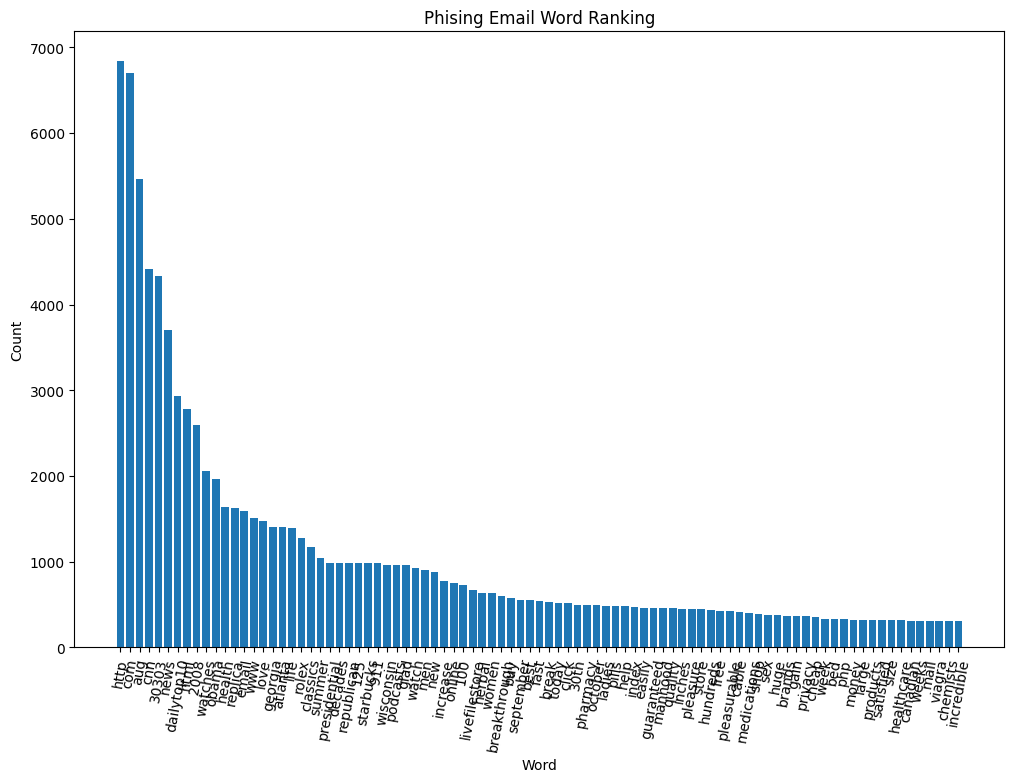

In [10]:
plt.figure(figsize=(12,8))
plt.bar(x, y)
plt.xlabel('Word')
plt.ylabel('Count')
plt.xticks(rotation=80)
plt.title('Phising Email Word Ranking')
plt.show()

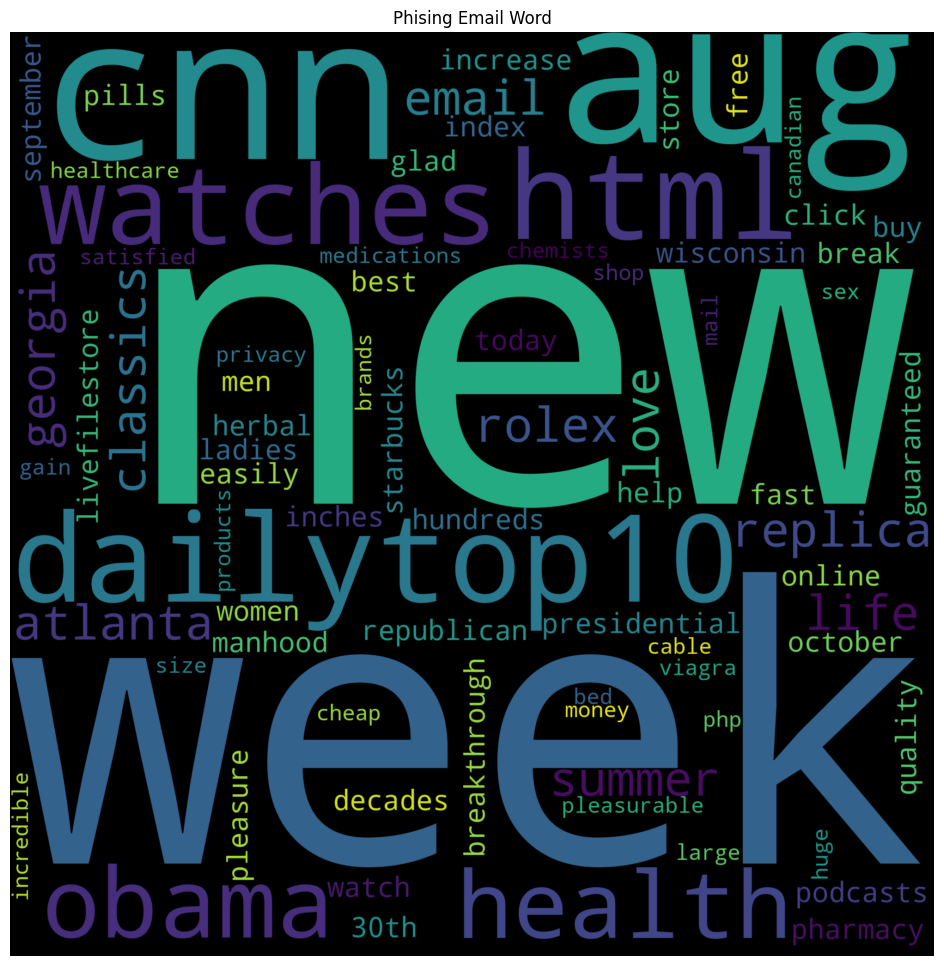

In [11]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

story_text = ' '.join(x)
wordcloud = WordCloud(width=2000, height=2000, background_color='black', max_words=200).generate(story_text)
plt.figure(figsize=(12,12))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Phising Email Word')
plt.show()